In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [2]:
# --- Step 1: Define Universe & Parameters ---
# Using a mix of large-caps and specific equities + NIFTY 50 as the benchmark
TICKERS = ["RELIANCE.NS", "HDFCBANK.NS", "TCS.NS", "INFY.NS", "ICICIBANK.NS", "PCBL.NS", "FEDERALBNK.NS"]
BENCHMARK = "^NSEI"
START_DATE = "2023-01-01"
END_DATE = "2026-02-26"
TRANSACTION_COST = 0.001  # 0.1% per trade

In [3]:
print("📡 Fetching market data from NSE...")
data = yf.download(TICKERS + [BENCHMARK], start=START_DATE, end=END_DATE)['Close']

prices = data[TICKERS].ffill().dropna()
benchmark_prices = data[BENCHMARK].ffill().dropna()

📡 Fetching market data from NSE...


[*********************100%***********************]  8 of 8 completed


In [4]:
# --- Step 2: Calculate Technical Indicators (Factors) ---
def calculate_rsi(series, window=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

In [5]:
print("🧮 Computing Momentum, RSI, and Moving Averages...")
# Create a dictionary to store our factor dataframes
factors = {}

🧮 Computing Momentum, RSI, and Moving Averages...


In [6]:
# 1. 200-Day Moving Average
factors['SMA_200'] = prices.rolling(window=200).mean()

In [7]:
# 2. 14-Day RSI
factors['RSI_14'] = prices.apply(calculate_rsi)

In [8]:
# 3. 3-Month Momentum (approx 63 trading days)
factors['Mom_3M'] = prices.pct_change(periods=63)

In [9]:
# 4. Daily Returns for the assets
daily_returns = prices.pct_change()

In [10]:
# --- Step 3: Define the Strategy Rules & Generate Signals ---
# Rule: Buy if Price > 200 MA AND RSI < 60 AND 3M Momentum > 0
# Rank the eligible stocks by 3M Momentum and hold the top 3.

In [11]:
# Create a boolean mask for our entry conditions
condition_ma = prices > factors['SMA_200']
condition_rsi = factors['RSI_14'] < 60
condition_mom = factors['Mom_3M'] > 0

In [12]:
eligible_stocks = condition_ma & condition_rsi & condition_mom

# Resample to monthly to get End of Month (EOM) rebalancing dates
eom_dates = prices.resample('ME').last().index

target_weights = pd.DataFrame(0.0, index=prices.index, columns=prices.columns)

In [13]:
print("⚖️ Executing Monthly Rebalancing & Applying Transaction Costs...")
for date in eom_dates:
    if date not in eligible_stocks.index:
        continue

    # Get eligible stocks for this specific month-end
    eligible_today = eligible_stocks.loc[date]
    valid_tickers = eligible_today[eligible_today].index

    if len(valid_tickers) > 0:
        # Rank by Momentum
        mom_scores = factors['Mom_3M'].loc[date, valid_tickers]
        top_picks = mom_scores.nlargest(3).index

        # Equal weight allocation among top picks
        weight_per_stock = 1.0 / len(top_picks)
        for ticker in top_picks:
            target_weights.loc[date, ticker] = weight_per_stock

⚖️ Executing Monthly Rebalancing & Applying Transaction Costs...


In [14]:
# Forward fill the weights until the next rebalance
# Shift by 1 day to prevent look-ahead bias (we trade the day AFTER the signal)
position_weights = target_weights.replace(0.0, np.nan).ffill().fillna(0.0).shift(1).fillna(0.0)

In [15]:
# --- Step 4: Backtest Engine (Performance & Costs) ---
# Calculate turnover to apply transaction costs
weight_changes = position_weights.diff().abs().fillna(0.0)
turnover_costs = weight_changes.sum(axis=1) * TRANSACTION_COST

In [16]:
# Portfolio Daily Return = (Weights * Stock Returns) - Trading Costs
port_returns = (position_weights * daily_returns).sum(axis=1) - turnover_costs

In [17]:
# Calculate cumulative growth
port_cumulative = (1 + port_returns).cumprod()
bench_cumulative = (1 + benchmark_prices.pct_change().fillna(0)).cumprod()

In [18]:
# --- Step 5: Evaluate Performance Metrics ---
def calc_metrics(returns, name):
    cum_ret = (1 + returns).cumprod()
    cagr = (cum_ret.iloc[-1] ** (252 / len(returns))) - 1

    roll_max = cum_ret.cummax()
    drawdown = (cum_ret - roll_max) / roll_max
    max_dd = drawdown.min()

    # Assuming 7% Risk-Free Rate
    sharpe = ((returns.mean() - (0.07/252)) / returns.std()) * np.sqrt(252)

    print(f"\n📊 {name} Performance:")
    print(f"  CAGR: {cagr*100:.2f}%")
    print(f"  Max Drawdown: {max_dd*100:.2f}%")
    print(f"  Sharpe Ratio: {sharpe:.2f}")

In [19]:
calc_metrics(port_returns, "Quant Strategy")
calc_metrics(benchmark_prices.pct_change().dropna(), "NIFTY 50 Benchmark")


📊 Quant Strategy Performance:
  CAGR: 15.97%
  Max Drawdown: -48.38%
  Sharpe Ratio: 0.40

📊 NIFTY 50 Benchmark Performance:
  CAGR: 11.52%
  Max Drawdown: -15.77%
  Sharpe Ratio: 0.39


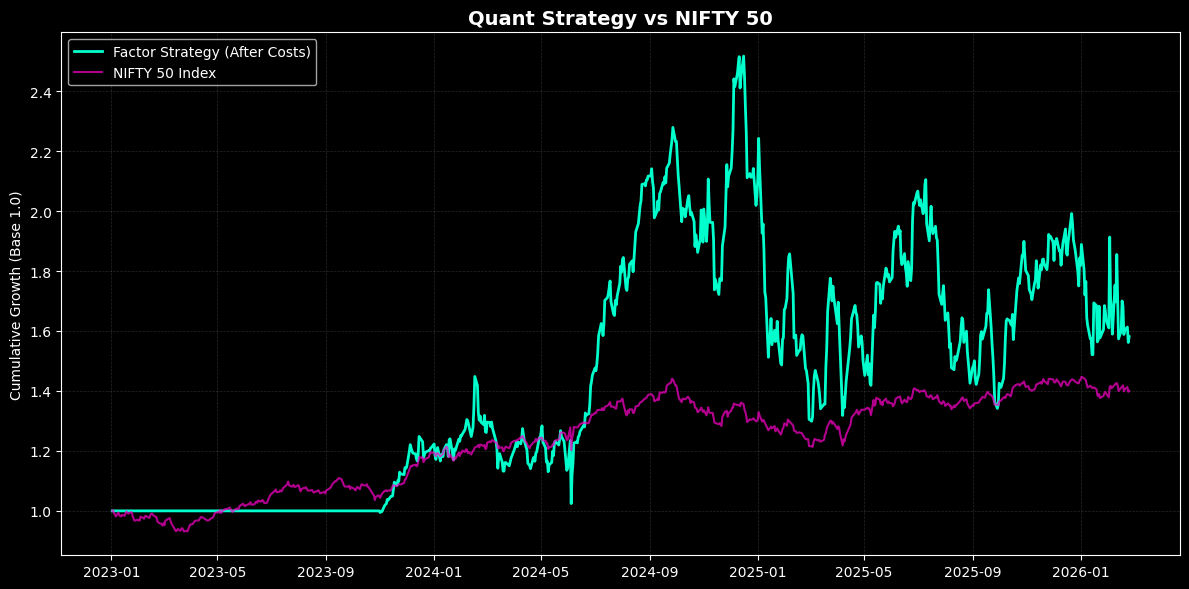

In [20]:
# --- Step 6: Plotting ---
plt.style.use('dark_background')
plt.figure(figsize=(12, 6))

plt.plot(port_cumulative.index, port_cumulative, label='Factor Strategy (After Costs)', color='#00ffcc', linewidth=2)
plt.plot(bench_cumulative.index, bench_cumulative, label='NIFTY 50 Index', color='#ff00cc', alpha=0.7, linewidth=1.5)

plt.title("Quant Strategy vs NIFTY 50", fontsize=14, fontweight='bold')
plt.ylabel("Cumulative Growth (Base 1.0)")
plt.legend(loc="upper left")
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.3)
plt.tight_layout()
plt.show()